In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option("display.max_rows", 1000)
pd.set_option("display.max_columns", None)

%config InlineBackend.figure_format = 'retina'

import msto
from importlib import reload
reload(msto);

In [111]:
isochrones = msto.fetch_isochrones(
    z_over_zsun= 0.2,
    logage_range= (6.0, 8.0),
    dlogage= 0.01,
)

tracks = {
    method: {
        "vals": msto.msto_f336w_track(
            isochrones=isochrones,
            prominence=0.01,
            method=method
        ),
        "label": label
    } for method, label in zip(["hook", "brightest"], ["Temperature derivatives", "Brightest MS point"])
}
for method in tracks:
    tracks[method]["interp"] = msto.make_msto_interpolator(tracks[method]["vals"][tracks[method]["vals"]["logAge"] > 6.6])

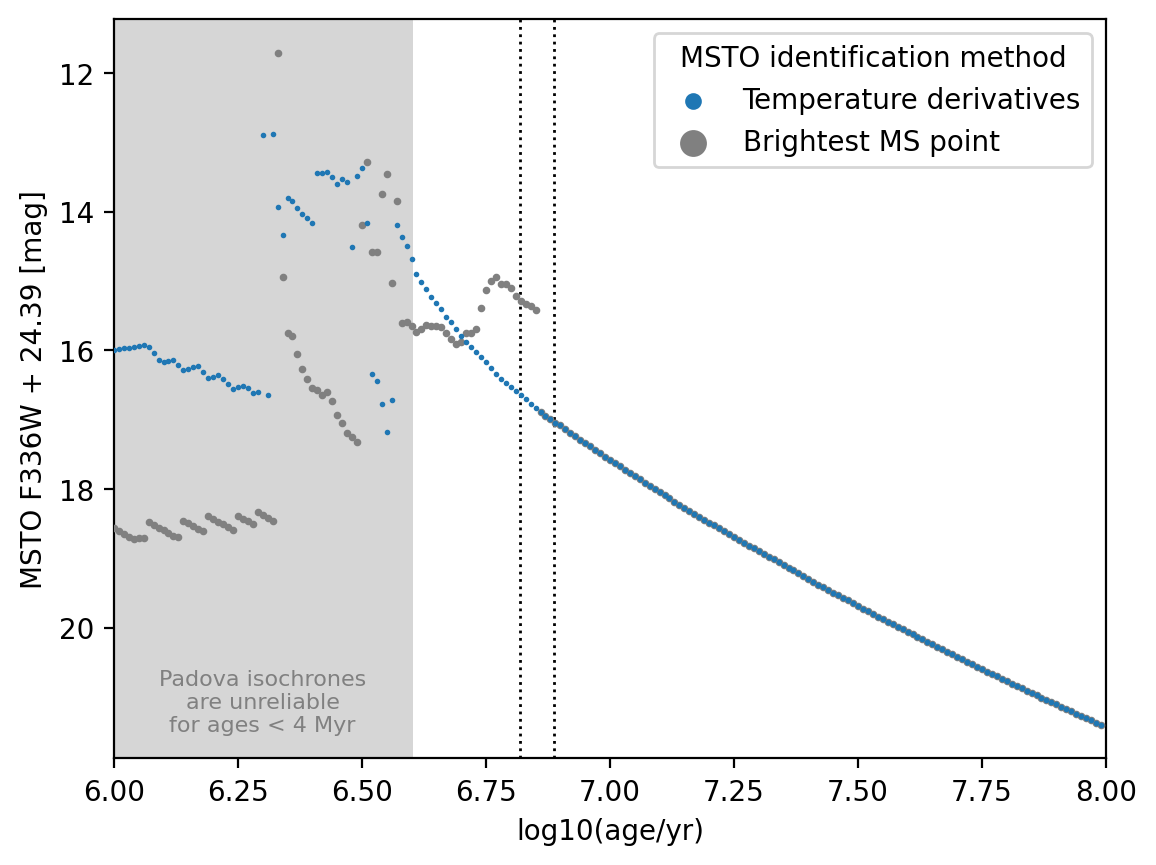

In [130]:
fig, ax = plt.subplots()

colours = ["tab:blue", "grey"]

for i, method in enumerate(tracks):
    ax.scatter(
        tracks[method]["vals"]["logAge"],
        tracks[method]["vals"]["msto_F336W"] + 24.39,
        s=1 + i * 2,
        label=tracks[method]["label"],
        zorder=10 - i,
        color=colours[i]
    )

ax.legend(loc="upper right", markerscale=5, title="MSTO identification method")
# plt.axvline(7.1)

ax.set_xlabel("log10(age/yr)")
ax.set_ylabel("MSTO F336W + 24.39 [mag]")

for val in [6.6e6, 7.7e6]:
    ax.axvline(np.log10(val), color="k", ls=":", lw=1)
    # ax.axhline(f(val) + 24.39, color="k", ls="--", lw=1)

# ax.axvline(7.21)
ax.axvspan(6, np.log10(4e6), color="#333", alpha=0.2, lw=0)
ax.annotate("Padova isochrones\nare unreliable\nfor ages < 4 Myr", xy=(6.3, 21.5), color="grey", fontsize=8, ha='center')

ax.set_xlim(6, 8)

ax.invert_yaxis()

plt.show()

In [117]:
tracks["hook"]["interp"](1e7)

array(-6.809092)

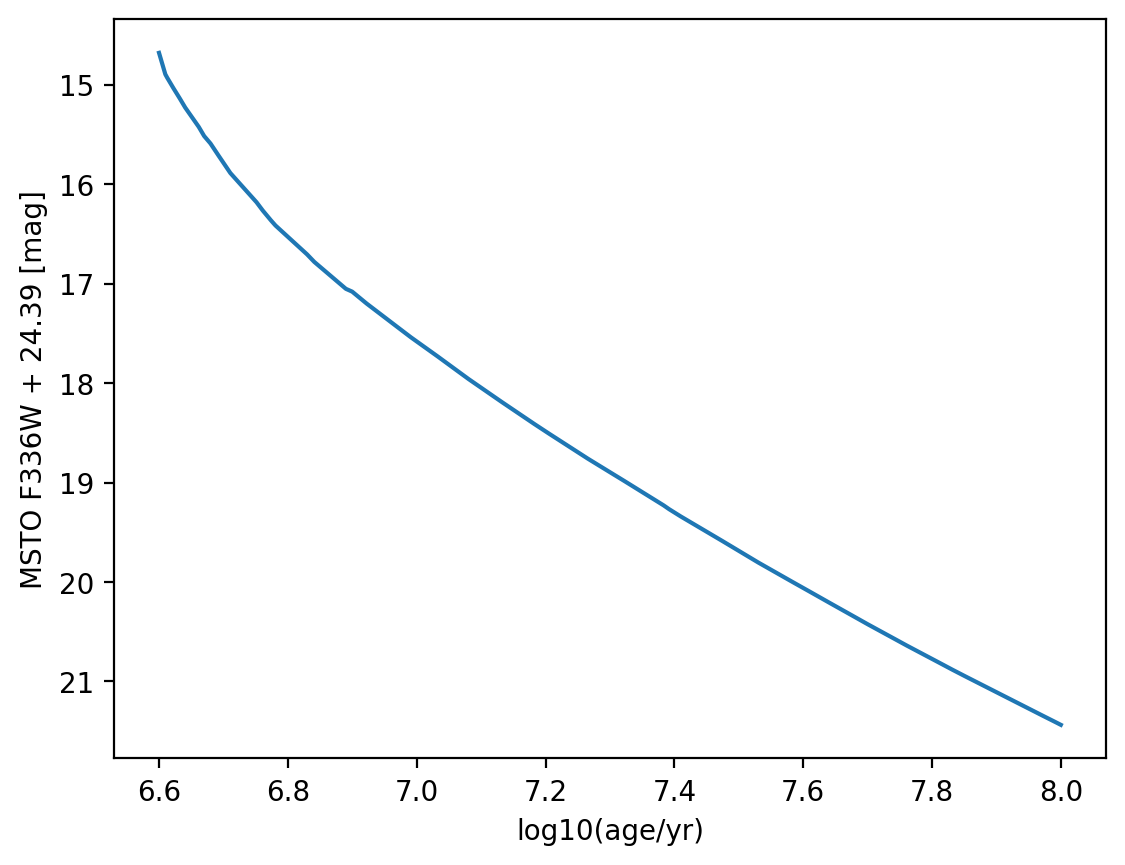

In [131]:
fig, ax = plt.subplots()

log_age_range = np.logspace(6.6, 8.0, 1000)

ax.plot(
    np.log10(log_age_range),
    tracks["hook"]["interp"](log_age_range) + 24.39,
    label=tracks["hook"]["label"]
)

# ax.set_xscale("log")

ax.invert_yaxis()
ax.set_xlabel("log10(age/yr)")
ax.set_ylabel("MSTO F336W + 24.39 [mag]")

plt.show()

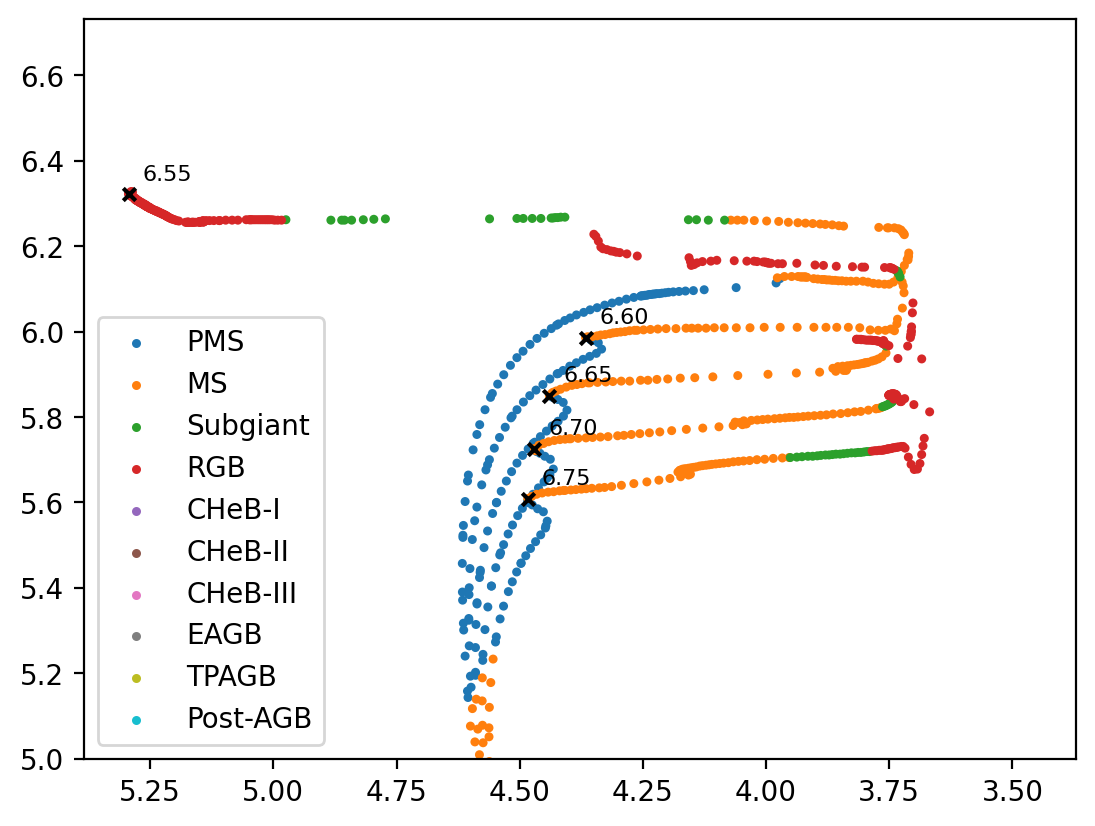

In [108]:
fig, ax = plt.subplots()

for logAge in np.arange(6.55, 6.75, 0.05):

    # find closest logAge in the isochrone table (not all ages are present)
    logAge = isochrones["logAge"].iloc[np.abs(isochrones["logAge"] - logAge).argmin()]
    # print(f"Plotting isochrone for logAge = {logAge:.3f}")

    iso = isochrones.query("logAge == @logAge")
    idx = msto.find_msto_index(iso["logTe"].values, prominence=0.01)

    scatter = ax.scatter(
        isochrones.query("logAge == @logAge")["logTe"],
        isochrones.query("logAge == @logAge")["logL"],
        c=[f'C{l}' for l in isochrones.query("logAge == @logAge")["label"].values],
        s=5,
    )
    ax.scatter(
        iso["logTe"].iloc[idx],
        iso["logL"].iloc[idx],
        c="k",
        s=20,
        marker="x",
    )
    ax.annotate(
        f"{logAge:.2f}",
        xy=(iso["logTe"].iloc[idx], iso["logL"].iloc[idx]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

labels = ["PMS", "MS", "Subgiant", "RGB", "CHeB-I", "CHeB-II", "CHeB-III", "EAGB", "TPAGB", "Post-AGB"]
for i, label in enumerate(labels):
    ax.scatter([], [], c=f'C{i}', label=label, s=5)
ax.legend()

ax.set_ylim(bottom=5)

ax.invert_xaxis()